# Notebook 04: Interaction features

Loads transformed data, scans ratio/product interactions, adds significant positive features, and saves output.

**Run Order**

| Step | Notebook | Purpose | Output |
|---|---|---|---|
| 1 | [01-EDA.ipynb](01-EDA.ipynb) | EDA and baseline profiling | `data/01-EDA.csv` |
| 2 | [02-outlier-cleaning.ipynb](02-outlier-cleaning.ipynb) | Outlier strategy evaluation and cleaning | `data/02-outlier-cleaning.csv` |
| 3 | [03-feature-transformations.ipynb](03-feature-transformations.ipynb) | Per-feature transform scans and apply | `data/03-feature-transformations.csv` |
| 4 | **[04-interaction-features.ipynb](04-interaction-features.ipynb)** | **Interaction scans and feature adds** | **`data/04-interaction-features.csv`** |
| 5 | [05-p_censoring.ipynb](05-p_censoring.ipynb) | OOF censoring probability feature | `data/x-final.csv` |

## 1. Notebook set-up

In [ ]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd

sys.path.insert(0, str(Path.cwd().resolve().parent / 'src'))
import featurely as fl

from config import DATA_DIR

## 2. Data loading

In [2]:
in_path = DATA_DIR / '03-feature-transformations.csv'

if not in_path.exists():
    raise FileNotFoundError(
        (f'Missing required input file: {in_path}. Run 03-feature-transformations.ipynb ' +
         'first to generate data/03-feature-transformations.csv.')
    )

housing_df = pd.read_csv(in_path)
features = [c for c in housing_df.columns if c != 'MedHouseVal']
print(f'Loaded: {in_path}')

Loaded: data/03-feature-transformations.csv


## 3. Interaction feature scans

In [ ]:
ratio_results = fl.run_pairwise_scan(
    housing_df,
    features,
    lambda a, b: a / b,
    'ratio'
 )

product_results = fl.run_pairwise_scan(
    housing_df,
    features,
    lambda a, b: a * b,
    'product',
    include_self=True
 )

Baseline R2 (in-sample): 0.6831

     ratio_MedInc_HouseAge: r = -0.0223,  p = 0.0014
     ratio_MedInc_AveRooms: r = -0.0111,  p = 0.1092
    ratio_MedInc_AveBedrms: r = -0.0025,  p = 0.7209
   ratio_MedInc_Population: r = -0.0171,  p = 0.0139
     ratio_MedInc_AveOccup: r = +0.0158,  p = 0.0229
     ratio_MedInc_Latitude: r = +0.0006,  p = 0.9321
    ratio_MedInc_Longitude: r = +0.0005,  p = 0.9375
   ratio_HouseAge_AveRooms: r = +0.0072,  p = 0.2992
  ratio_HouseAge_AveBedrms: r = +0.0014,  p = 0.8393
 ratio_HouseAge_Population: r = +0.0111,  p = 0.1102
   ratio_HouseAge_AveOccup: r = +0.0207,  p = 0.0029
   ratio_HouseAge_Latitude: r = +0.0040,  p = 0.5651
  ratio_HouseAge_Longitude: r = -0.0004,  p = 0.9565
  ratio_AveRooms_AveBedrms: r = -0.0037,  p = 0.5906
 ratio_AveRooms_Population: r = +0.0385,  p = 0.0000
   ratio_AveRooms_AveOccup: r = +0.0200,  p = 0.0041
   ratio_AveRooms_Latitude: r = -0.0020,  p = 0.7741
  ratio_AveRooms_Longitude: r = +0.0005,  p = 0.9456
ratio_AveBedr

## 4. Plotting configuration

In [4]:
scan_configs = [
    ('ratio', 'ratio', ratio_results, '#ed7d31', lambda a, b: a / b),
    ('product', 'product', product_results, '#70ad47', lambda a, b: a * b),
]

## 5. Per-feature results

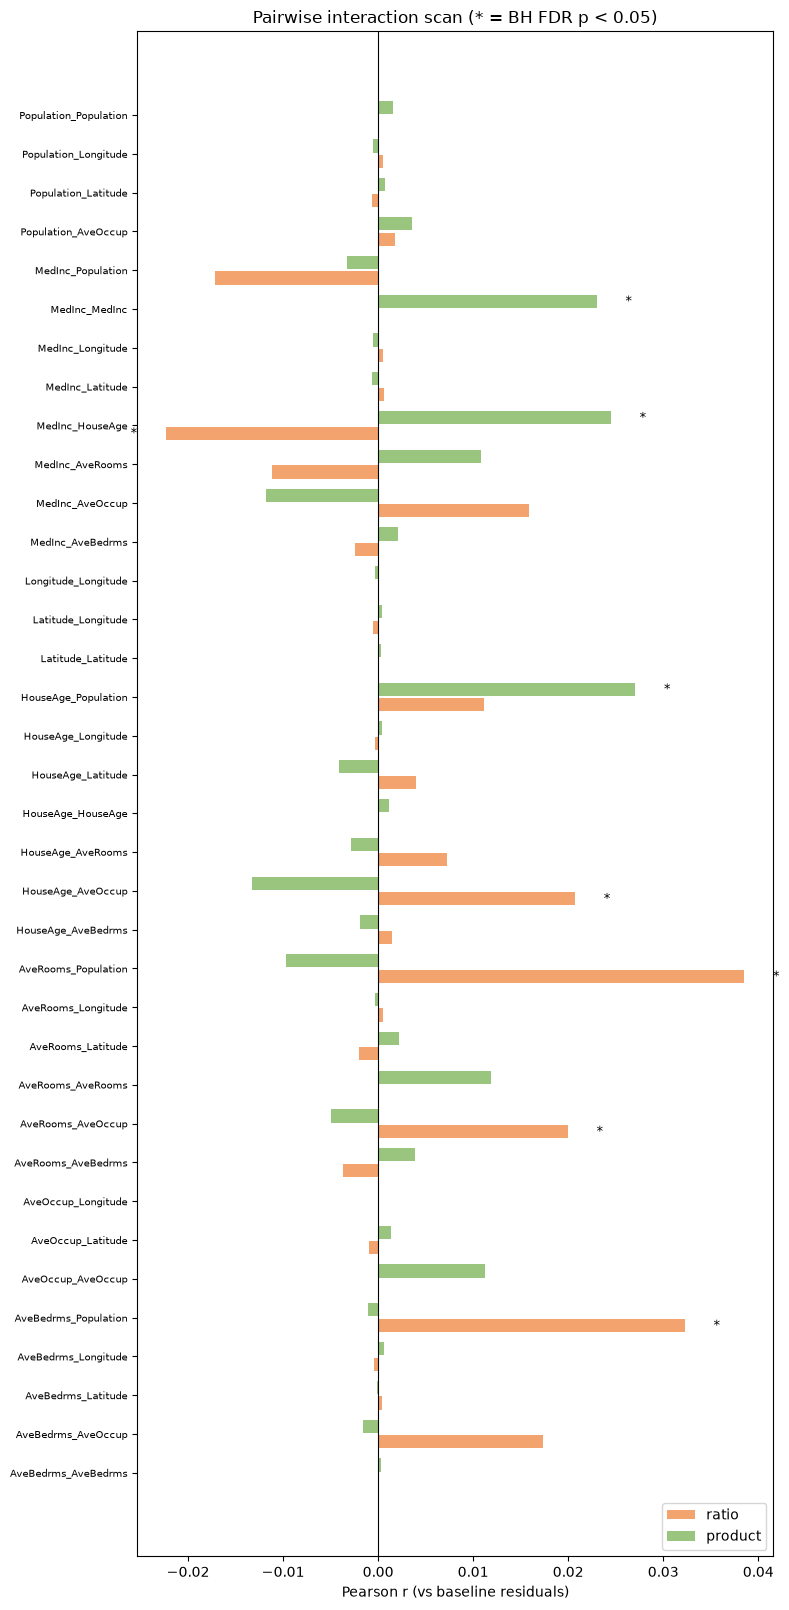

In [ ]:
pairwise_sig_dict = fl.plot_combined_pairwise_scan(
    scan_configs,
    title='Pairwise interaction scan (* = BH FDR p < 0.05)'
)

## 6. Significant transforms vs baseline residuals

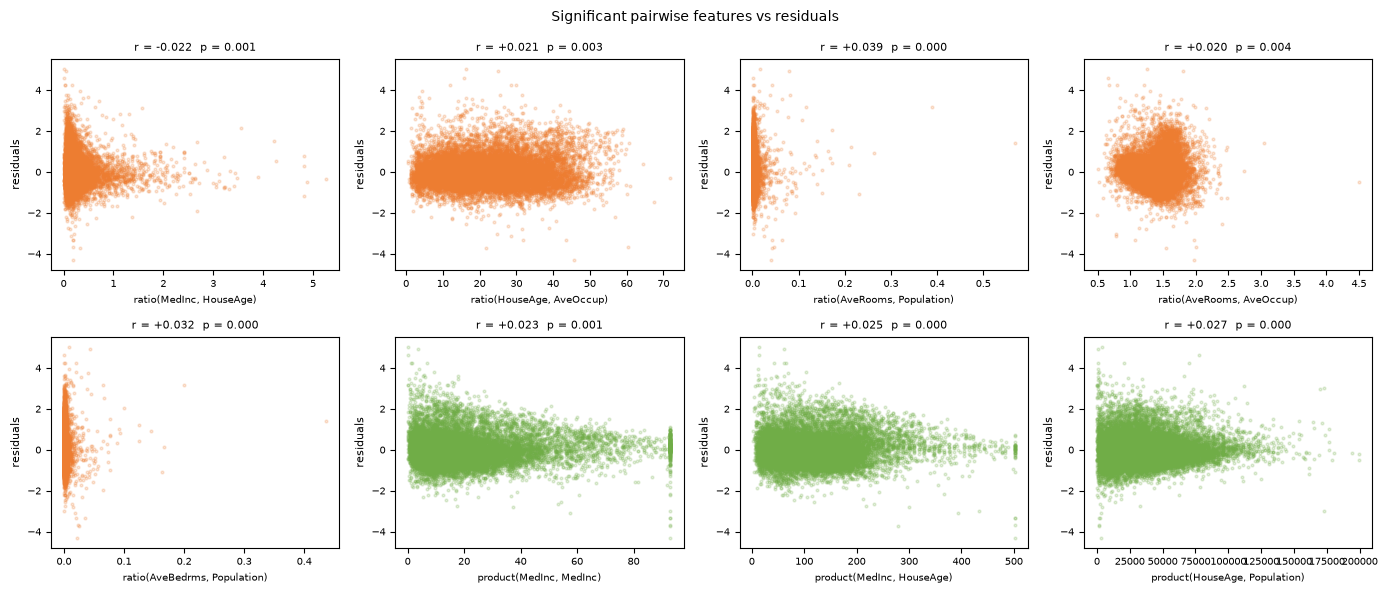

In [ ]:
fl.plot_significant_pairwise_scatters(
    scan_configs,
    pairwise_sig_dict,
    housing_df,
    title='Significant pairwise features vs residuals'
)

## 7. Add interaction features

In [7]:
op_fns = {'ratio': lambda a, b: a / b, 'product': lambda a, b: a * b}
to_add = {}

for prefix, op_name, results, _, _ in scan_configs:
    for label, (r, _) in results.items():

        pair_suffix = label[len(prefix) + 1:]
        is_sig = pairwise_sig_dict.get((op_name, pair_suffix), False)

        if not is_sig or r <= 0:
            continue

        found = False

        for col_a in features:
            for col_b in features:
                if pair_suffix == f'{col_a}_{col_b}':

                    vals = op_fns[prefix](housing_df[col_a], housing_df[col_b])

                    if np.isfinite(vals).all():
                        to_add[f'{prefix}_{col_a}_{col_b}'] = vals

                    found = True
                    break

            if found:
                break

if to_add:
    housing_df = pd.concat([housing_df, pd.DataFrame(to_add, index=housing_df.index)], axis=1)
    print(f'Added {len(to_add)} interaction feature(s).')

else:
    print('No interaction features passed significance threshold.')

Added 7 interaction feature(s).


## 8. Save output

In [8]:
out_path = DATA_DIR / '04-interaction-features.csv'
housing_df.to_csv(out_path, index=False)
print(f'Saved: {out_path}')

Saved: data/04-interaction-features.csv
